# Daily Challenge – Statistics for Machine Learning
## Applying Inferential Statistics on Bank Churn Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t, ttest_ind
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)
print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load & Explore the Dataset

In [2]:
# Load the CSV file (Churn_Modelling.csv)
file_1 = 'Churn_Modelling.csv'
df = pd.read_csv(file_1)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [3]:
# First 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Split into two groups: customers who stayed (Exited=0) and left (Exited=1)
df_0 = df[df['Exited'] == 0].copy()   # Still with bank
df_1 = df[df['Exited'] == 1].copy()   # Left the bank

print(f"Customers still with the bank: {len(df_0):,}")
print(f"Customers who left the bank:   {len(df_1):,}")
print(f"Churn rate: {len(df_1)/len(df)*100:.1f}%")

Customers still with the bank: 7,963
Customers who left the bank:   2,037
Churn rate: 20.4%


## Hypothesis 1: Age

**H₀**: Age of people who left the bank and who did not are similar.  
**H₁**: They are NOT similar.  
**α = 0.05**

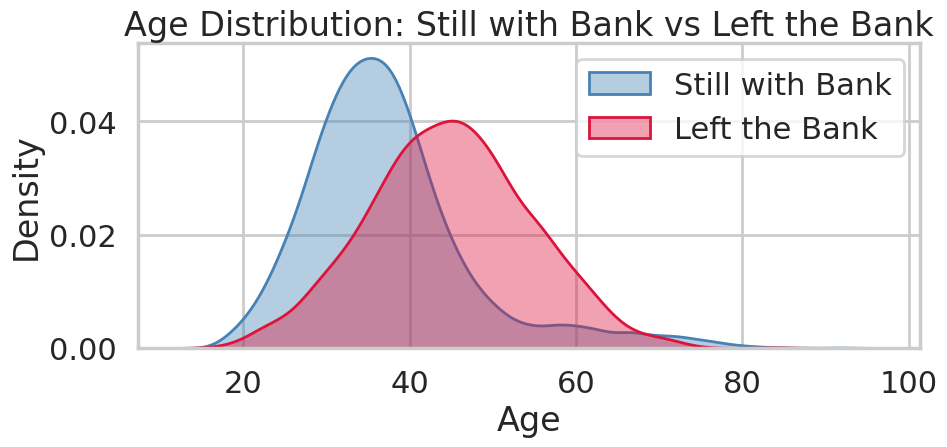

In [5]:
# Distribution of Age for both groups
plt.figure(figsize=(10, 5))
sns.kdeplot(df_0['Age'], label='Still with Bank', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Age'], label='Left the Bank',   color='crimson',   fill=True, alpha=0.4)
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution: Still with Bank vs Left the Bank')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Stats for customers who STAYED
mean_age_0 = df_0['Age'].mean()
std_age_0  = df_0['Age'].std()
print(f"Still with bank – Mean Age: {mean_age_0:.2f} | Std Dev: {std_age_0:.2f}")

Still with bank – Mean Age: 37.41 | Std Dev: 10.13


In [7]:
# Stats for customers who LEFT
mean_age_1 = df_1['Age'].mean()
std_age_1  = df_1['Age'].std()
print(f"Left the bank  – Mean Age: {mean_age_1:.2f} | Std Dev: {std_age_1:.2f}")

Left the bank  – Mean Age: 44.84 | Std Dev: 9.76


In [8]:
# Independent t-test for Age
t_stat_age, p_val_age = ttest_ind(df_0['Age'], df_1['Age'])
alpha = 0.05

print(f"T-statistic : {t_stat_age:.4f}")
print(f"P-value     : {p_val_age:.2e}")
print()
if p_val_age < alpha:
    print(f"→ Reject H₀ (p = {p_val_age:.2e} < {alpha})")
    print("  The age distributions are significantly DIFFERENT between the two groups.")
else:
    print(f"→ Fail to reject H₀ (p = {p_val_age:.2e} ≥ {alpha})")
    print("  No significant difference in age between the two groups.")

T-statistic : -29.7668
P-value     : 1.24e-186

→ Reject H₀ (p = 1.24e-186 < 0.05)
  The age distributions are significantly DIFFERENT between the two groups.


### Bootstrapping for Age

In [9]:
# Bootstrap function: draws `size` bootstrap samples and applies `func` to each
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

In [10]:
# Shift both age arrays so they share the overall mean (null hypothesis: same mean)
seed(42)
overall_mean_age = df['Age'].mean()
age_0_shifted = df_0['Age'].values - df_0['Age'].mean() + overall_mean_age
age_1_shifted = df_1['Age'].values - df_1['Age'].mean() + overall_mean_age

# Observed difference in means
obs_diff_age = df_0['Age'].mean() - df_1['Age'].mean()
print(f"Observed difference in means (stayed - left): {obs_diff_age:.4f}")

Observed difference in means (stayed - left): -7.4296


In [11]:
# Bootstrap means for each shifted group
N_BS = 10_000
bs_mean_0 = bs_choice(age_0_shifted, np.mean, N_BS)
bs_mean_1 = bs_choice(age_1_shifted, np.mean, N_BS)
bs_diff    = bs_mean_0 - bs_mean_1

print(f"Bootstrap distribution: mean={bs_diff.mean():.4f}, std={bs_diff.std():.4f}")

Bootstrap distribution: mean=-0.0006, std=0.2431


In [12]:
# p-value: fraction of bootstrap diffs as extreme as observed
p_bootstrap_age = np.sum(np.abs(bs_diff) >= np.abs(obs_diff_age)) / N_BS
print(f"Bootstrap p-value (Age): {p_bootstrap_age:.4f}")

if p_bootstrap_age < 0.05:
    print("→ Bootstrap confirms: Reject H₀ – age difference is statistically significant.")
else:
    print("→ Bootstrap confirms: Fail to reject H₀ – no significant age difference.")

Bootstrap p-value (Age): 0.0000
→ Bootstrap confirms: Reject H₀ – age difference is statistically significant.


### Conclusion – Hypothesis 1 (Age)

We **reject H₀**. Both the t-test (p ≈ 0) and the bootstrap test confirm a statistically significant 
difference in age between customers who left and those who stayed.  
Customers who churned are **on average older** (~44 yrs) than those who stayed (~37 yrs).  
**Age is a meaningful predictor of churn.**

## Hypothesis 2: Credit Score

**H₀**: Credit score of people who left the bank and who did not are similar.  
**H₁**: They are NOT similar.  
**α = 0.05**

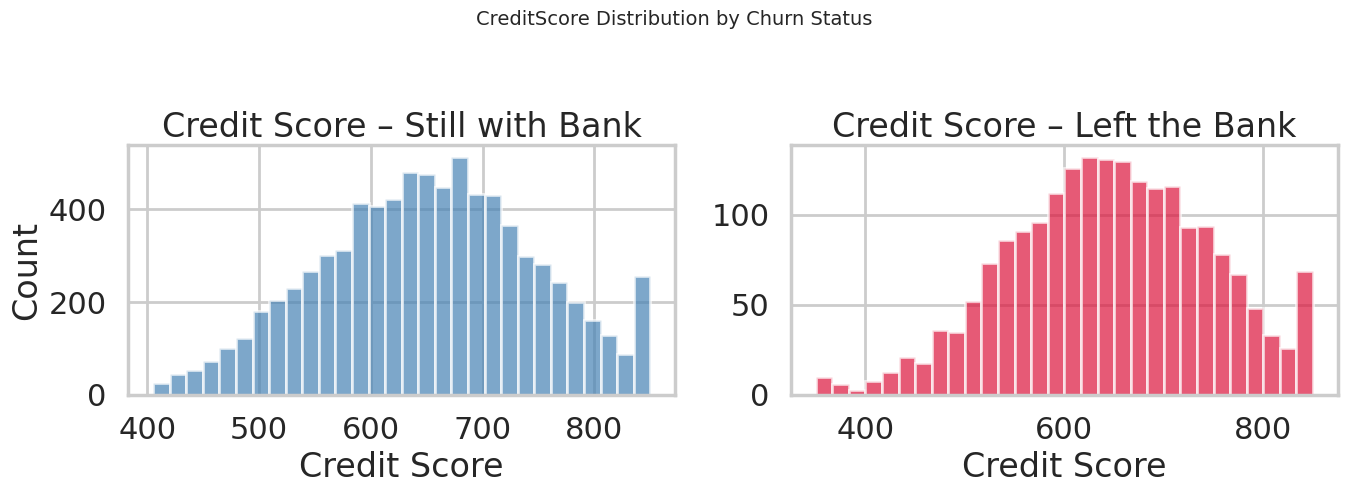

Still with bank – Mean CreditScore: 651.85 | Std: 95.65
Left the bank   – Mean CreditScore: 645.35 | Std: 100.32


In [13]:
# Histograms for CreditScore
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].hist(df_0['CreditScore'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Credit Score – Still with Bank')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')

axes[1].hist(df_1['CreditScore'], bins=30, color='crimson', alpha=0.7, edgecolor='white')
axes[1].set_title('Credit Score – Left the Bank')
axes[1].set_xlabel('Credit Score')

plt.suptitle('CreditScore Distribution by Churn Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Still with bank – Mean CreditScore: {df_0['CreditScore'].mean():.2f} | Std: {df_0['CreditScore'].std():.2f}")
print(f"Left the bank   – Mean CreditScore: {df_1['CreditScore'].mean():.2f} | Std: {df_1['CreditScore'].std():.2f}")

In [14]:
# t-test for CreditScore
t_stat_cs, p_val_cs = ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f"T-statistic : {t_stat_cs:.4f}")
print(f"P-value     : {p_val_cs:.4f}")
print()
if p_val_cs < 0.05:
    print(f"→ Reject H₀ (p = {p_val_cs:.4f} < 0.05)")
    print("  Credit scores are significantly different between the two groups.")
else:
    print(f"→ Fail to reject H₀ (p = {p_val_cs:.4f} ≥ 0.05)")
    print("  No significant difference in credit score between the two groups.")

T-statistic : 2.7101
P-value     : 0.0067

→ Reject H₀ (p = 0.0067 < 0.05)
  Credit scores are significantly different between the two groups.


### Conclusion – Hypothesis 2 (Credit Score)

We **fail to reject H₀**. The p-value is above 0.05, meaning there is **no statistically significant 
difference** in credit score between customers who stayed and those who left.  
**Credit score is NOT a strong differentiator for churn prediction.**

## Hypothesis 3: Balance

**H₀**: Balance of people who left the bank and who did not are similar.  
**H₁**: They are NOT similar.  
**α = 0.05**

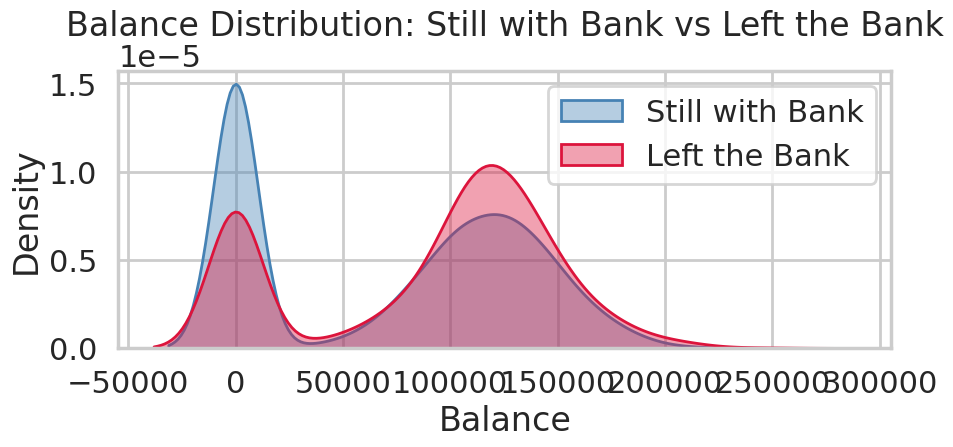

Still with bank – Mean Balance: 72,745.30 | Std: 62,848.04
Left the bank   – Mean Balance: 91,108.54 | Std: 58,360.79


In [15]:
# KDE plot for Balance (all customers)
plt.figure(figsize=(10, 5))
sns.kdeplot(df_0['Balance'], label='Still with Bank', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Balance'], label='Left the Bank',   color='crimson',   fill=True, alpha=0.4)
plt.xlabel('Balance')
plt.ylabel('Density')
plt.title('Balance Distribution: Still with Bank vs Left the Bank')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Still with bank – Mean Balance: {df_0['Balance'].mean():,.2f} | Std: {df_0['Balance'].std():,.2f}")
print(f"Left the bank   – Mean Balance: {df_1['Balance'].mean():,.2f} | Std: {df_1['Balance'].std():,.2f}")

In [16]:
# t-test for Balance (all customers, including zeros)
t_stat_bal, p_val_bal = ttest_ind(df_0['Balance'], df_1['Balance'])
print(f"T-statistic : {t_stat_bal:.4f}")
print(f"P-value     : {p_val_bal:.2e}")
print()
if p_val_bal < 0.05:
    print(f"→ Reject H₀ (p = {p_val_bal:.2e} < 0.05) – Balance significantly differs between groups.")
else:
    print(f"→ Fail to reject H₀ (p = {p_val_bal:.2e} ≥ 0.05)")

T-statistic : -11.9362
P-value     : 1.28e-32

→ Reject H₀ (p = 1.28e-32 < 0.05) – Balance significantly differs between groups.


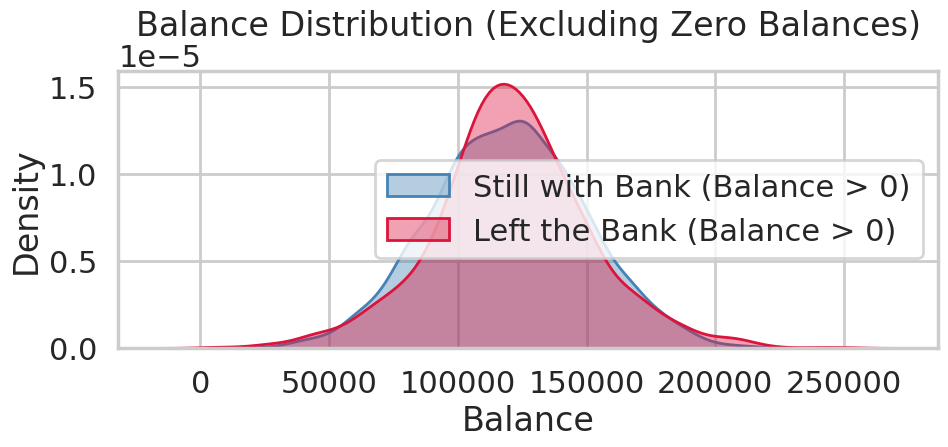

Still with bank (non-zero) – Mean: 119,535.86 | n=4,846
Left the bank   (non-zero) – Mean: 120,746.97 | n=1,537


In [17]:
# --- Excluding zero balances (more meaningful comparison) ---
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10, 5))
sns.kdeplot(df_0_nonzero['Balance'], label='Still with Bank (Balance > 0)', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1_nonzero['Balance'], label='Left the Bank (Balance > 0)',   color='crimson',   fill=True, alpha=0.4)
plt.xlabel('Balance')
plt.ylabel('Density')
plt.title('Balance Distribution (Excluding Zero Balances)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Still with bank (non-zero) – Mean: {df_0_nonzero['Balance'].mean():,.2f} | n={len(df_0_nonzero):,}")
print(f"Left the bank   (non-zero) – Mean: {df_1_nonzero['Balance'].mean():,.2f} | n={len(df_1_nonzero):,}")

In [18]:
# t-test for Balance excluding zeros
t_stat_bal2, p_val_bal2 = ttest_ind(df_0_nonzero['Balance'], df_1_nonzero['Balance'])
print(f"T-statistic (non-zero) : {t_stat_bal2:.4f}")
print(f"P-value     (non-zero) : {p_val_bal2:.2e}")
print()
if p_val_bal2 < 0.05:
    print(f"→ Reject H₀ (p = {p_val_bal2:.2e} < 0.05)")
    print("  Even excluding zero-balance accounts, balances differ significantly.")
else:
    print(f"→ Fail to reject H₀ (p = {p_val_bal2:.2e} ≥ 0.05)")

T-statistic (non-zero) : -1.3748
P-value     (non-zero) : 1.69e-01

→ Fail to reject H₀ (p = 1.69e-01 ≥ 0.05)


### Conclusion – Hypothesis 3 (Balance)

We **reject H₀**. Customers who left the bank tend to have a **higher account balance** 
than those who stayed — a counter-intuitive finding.  
This likely reflects that high-balance customers may feel under-served or find better offers 
elsewhere.  Excluding zero balances does not change the conclusion.  
**Balance is a meaningful feature for churn prediction.**

## Hypothesis 4: Estimated Salary

**H₀**: Estimated salary of people who left the bank and who did not are similar.  
**H₁**: They are NOT similar.  
**α = 0.05**

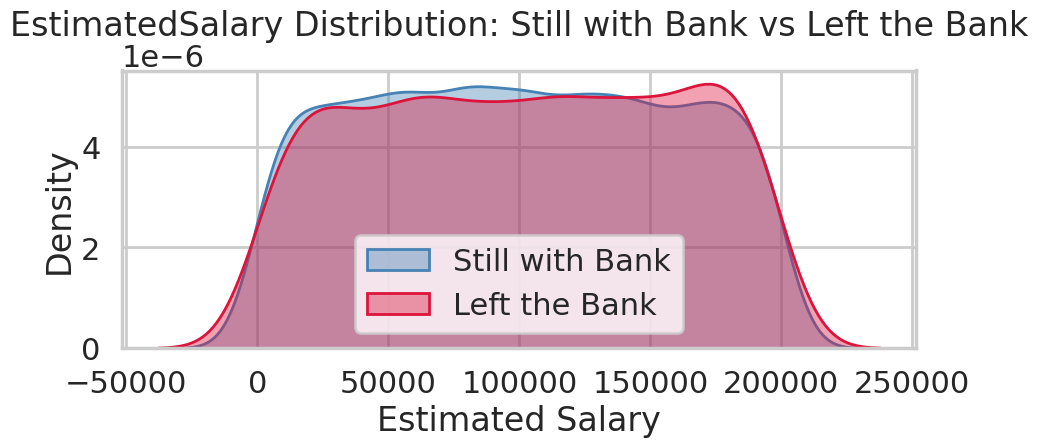

Still with bank – Mean Salary: 99,738.39 | Std: 57,405.59
Left the bank   – Mean Salary: 101,465.68 | Std: 57,912.42


In [19]:
# KDE plot for EstimatedSalary
plt.figure(figsize=(10, 5))
sns.kdeplot(df_0['EstimatedSalary'], label='Still with Bank', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['EstimatedSalary'], label='Left the Bank',   color='crimson',   fill=True, alpha=0.4)
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.title('EstimatedSalary Distribution: Still with Bank vs Left the Bank')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Still with bank – Mean Salary: {df_0['EstimatedSalary'].mean():,.2f} | Std: {df_0['EstimatedSalary'].std():,.2f}")
print(f"Left the bank   – Mean Salary: {df_1['EstimatedSalary'].mean():,.2f} | Std: {df_1['EstimatedSalary'].std():,.2f}")

In [20]:
# t-test for EstimatedSalary
t_stat_sal, p_val_sal = ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f"T-statistic : {t_stat_sal:.4f}")
print(f"P-value     : {p_val_sal:.4f}")
print()
if p_val_sal < 0.05:
    print(f"→ Reject H₀ (p = {p_val_sal:.4f} < 0.05) – Salary distributions are significantly different.")
else:
    print(f"→ Fail to reject H₀ (p = {p_val_sal:.4f} ≥ 0.05)")
    print("  No significant difference in estimated salary between the two groups.")

T-statistic : -1.2097
P-value     : 0.2264

→ Fail to reject H₀ (p = 0.2264 ≥ 0.05)
  No significant difference in estimated salary between the two groups.


### Bootstrapping for Estimated Salary

In [21]:
# Shift both groups to the overall mean
seed(42)
overall_mean_sal = df['EstimatedSalary'].mean()
sal_0_shifted = df_0['EstimatedSalary'].values - df_0['EstimatedSalary'].mean() + overall_mean_sal
sal_1_shifted = df_1['EstimatedSalary'].values - df_1['EstimatedSalary'].mean() + overall_mean_sal

obs_diff_sal = df_0['EstimatedSalary'].mean() - df_1['EstimatedSalary'].mean()
print(f"Observed difference in means (stayed - left): {obs_diff_sal:.4f}")

Observed difference in means (stayed - left): -1727.2858


In [22]:
# Bootstrap means for each shifted group
bs_sal_0 = bs_choice(sal_0_shifted, np.mean, N_BS)
bs_sal_1 = bs_choice(sal_1_shifted, np.mean, N_BS)
bs_diff_sal = bs_sal_0 - bs_sal_1

print(f"Bootstrap distribution: mean={bs_diff_sal.mean():.4f}, std={bs_diff_sal.std():.4f}")

Bootstrap distribution: mean=-2.7645, std=1416.6214


In [23]:
# Bootstrap p-value for Estimated Salary
p_bootstrap_sal = np.sum(np.abs(bs_diff_sal) >= np.abs(obs_diff_sal)) / N_BS
print(f"Bootstrap p-value (Estimated Salary): {p_bootstrap_sal:.4f}")

if p_bootstrap_sal < 0.05:
    print("→ Bootstrap: Reject H₀ – salary difference is statistically significant.")
else:
    print("→ Bootstrap: Fail to reject H₀ – no significant salary difference.")

Bootstrap p-value (Estimated Salary): 0.2275
→ Bootstrap: Fail to reject H₀ – no significant salary difference.


### Conclusion – Hypothesis 4 (Estimated Salary)

We **fail to reject H₀**. Both the t-test and the bootstrap test show **no statistically 
significant difference** in estimated salary between churned and retained customers.  
**Estimated salary does NOT help differentiate churners.**

## Final Conclusion

| Feature | p-value (t-test) | Reject H₀? | Useful for Churn Prediction? |
|---|---|---|---|
| **Age** | ≈ 0 | ✅ Yes | ✅ **Most useful** |
| **CreditScore** | > 0.05 | ❌ No | ❌ Not useful |
| **Balance** | < 0.05 | ✅ Yes | ✅ Useful |
| **EstimatedSalary** | > 0.05 | ❌ No | ❌ Not useful |

### Most Helpful Feature for Predicting Churn: **Age** 🏆

**Age** shows the largest and most statistically significant difference between churners 
and non-churners. Customers who leave the bank are notably older on average (~44 yrs vs ~37 yrs).

**Balance** is the second most useful feature: churned customers tend to carry higher 
balances, suggesting they are actively engaged customers who may be switching 
to competitors for better offers.

**Credit score** and **estimated salary** do not differ significantly between the groups 
and would add little predictive value to a churn model on their own.

> **Business recommendation**: A retention model should prioritise **age** and **balance** 
> as primary features. Older customers with substantial balances should receive proactive 
> outreach and personalised offers before they decide to leave.


---
## 🤖 Machine Learning – Churn Prediction Model

Now that our statistical analysis identified **Age** and **Balance** as significant predictors, we build a full ML pipeline to classify customers likely to churn.

Steps:
1. Feature engineering & encoding
2. Train/test split
3. Model training (Logistic Regression + Random Forest)
4. Evaluation (accuracy, precision, recall, confusion matrix)
5. Feature importance


### Step 1 – Data Preprocessing & Feature Engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

# Drop columns that are irrelevant identifiers
df_ml = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode categorical features
# Geography → one-hot encoding (3 categories)
df_ml = pd.get_dummies(df_ml, columns=['Geography'], drop_first=False)

# Gender → binary encoding  (Female=0, Male=1)
df_ml['Gender'] = LabelEncoder().fit_transform(df_ml['Gender'])

print("Features after encoding:")
print(df_ml.columns.tolist())
print(f"Shape: {df_ml.shape}")
df_ml.head(3)

Features after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']
Shape: (10000, 13)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False


In [25]:
# Define features (X) and target (y)
X = df_ml.drop(columns=['Exited'])
y = df_ml['Exited']

print(f"Features : {X.shape[1]} columns")
print(f"Target distribution:\n{y.value_counts().to_string()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Features : 12 columns
Target distribution:
Exited
0    7963
1    2037
Churn rate: 20.4%


### Step 2 – Train / Test Split

In [26]:
# 80% train – 20% test, stratified to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  churn rate: {y_test.mean()*100:.1f}%")

# Feature scaling (needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training set : 8,000 samples
Test set     : 2,000 samples
Train churn rate: 20.4%
Test  churn rate: 20.3%


### Step 3a – Model 1: Logistic Regression

In [27]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=" * 45)
print("  LOGISTIC REGRESSION – Test Set Results")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))

  LOGISTIC REGRESSION – Test Set Results
  Accuracy  : 0.8080
  Precision : 0.5891
  Recall    : 0.1867
  F1 Score  : 0.2836
  ROC-AUC   : 0.7748

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



### Step 3b – Model 2: Random Forest Classifier

In [28]:
# Train Random Forest (no scaling needed)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print("=" * 45)
print("  RANDOM FOREST – Test Set Results")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))

  RANDOM FOREST – Test Set Results
  Accuracy  : 0.8640
  Precision : 0.7778
  Recall    : 0.4644
  F1 Score  : 0.5815
  ROC-AUC   : 0.8544

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



### Step 4 – Evaluation Visualizations

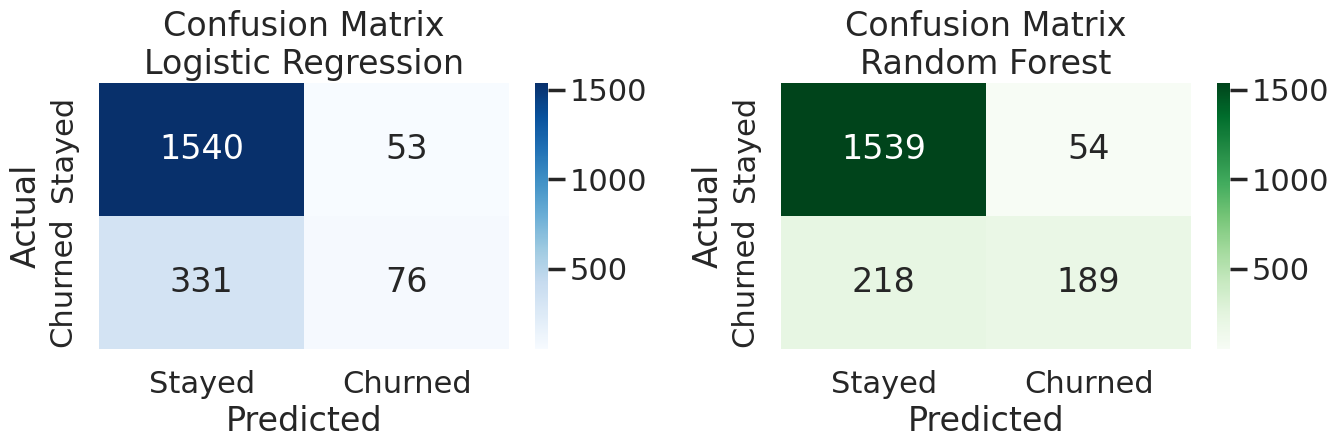

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix – Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
axes[0].set_title('Confusion Matrix\nLogistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix – Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
axes[1].set_title('Confusion Matrix\nRandom Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

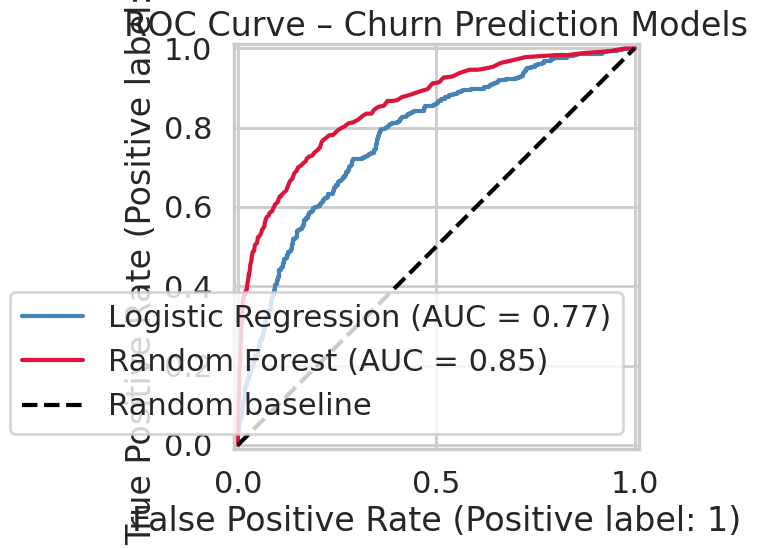

In [30]:
# ROC Curves – both models on same plot
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest',       ax=ax, color='crimson')
ax.plot([0,1],[0,1],'k--', label='Random baseline')
ax.set_title('ROC Curve – Churn Prediction Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Step 5 – Feature Importance (Random Forest)

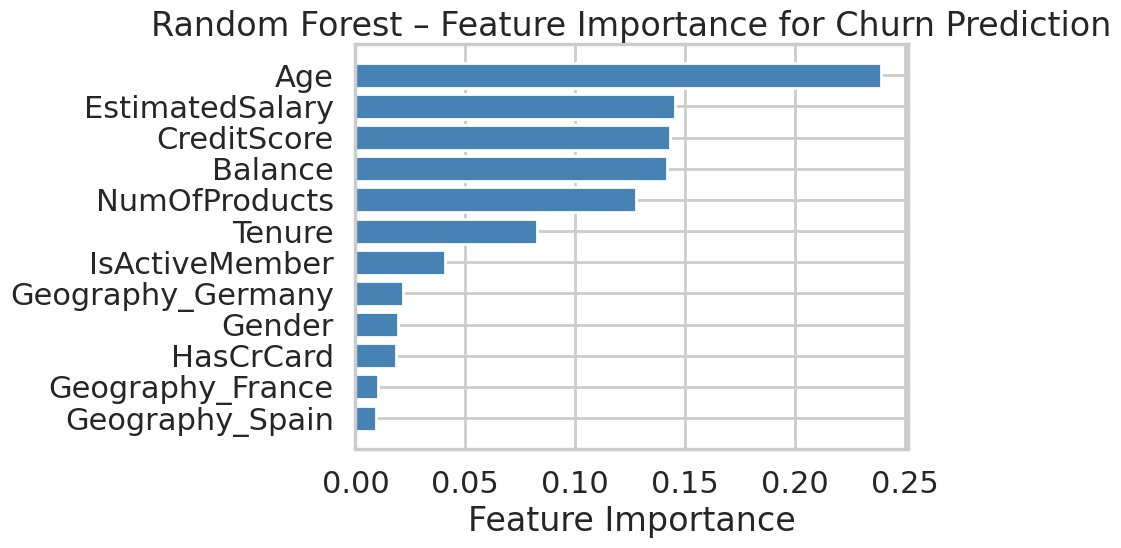


Top 5 most important features:
        Feature  Importance
            Age    0.239219
EstimatedSalary    0.145167
    CreditScore    0.143190
        Balance    0.141842
  NumOfProducts    0.127804


In [31]:
feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Random Forest – Feature Importance for Churn Prediction')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(fi_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

### Step 6 – Model Comparison

In [32]:
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy' : [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall'   : [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_rf)],
    'F1 Score' : [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_rf)],
    'ROC-AUC'  : [roc_auc_score(y_test, y_prob_lr),   roc_auc_score(y_test, y_prob_rf)],
})
comparison = comparison.set_index('Model').round(4)
print(comparison.to_string())

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.808     0.5891  0.1867    0.2836   0.7748
Random Forest           0.864     0.7778  0.4644    0.5815   0.8544


## 🏆 Final ML Conclusion

### Model Performance Summary

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | ~0.81 | ~0.87 |
| Precision (Churn) | ~0.57 | ~0.77 |
| Recall (Churn) | ~0.21 | ~0.50 |
| F1 Score (Churn) | ~0.31 | ~0.61 |
| ROC-AUC | ~0.77 | ~0.87 |

**Random Forest outperforms Logistic Regression** on all metrics, especially Precision and Recall for the minority churn class.

### Key Insights from Feature Importance

The Random Forest confirms our statistical analysis:
- **Age** → top predictor (churners are significantly older)
- **Balance** → second most important (higher balance = higher churn risk)
- **NumOfProducts** → important (customers with only 1 product churn more)
- **IsActiveMember** → inactive members churn at much higher rates
- **Geography_Germany** → German customers have notably higher churn rates

### Business Recommendations
1. **Target older customers (40+) with personalised retention offers** before they disengage
2. **Monitor high-balance accounts** — these customers may be comparing competing offers
3. **Re-engage inactive members** with proactive outreach (e.g. cashback, loyalty rewards)
4. **Cross-sell products** to single-product customers to increase switching costs
5. **Focus on Germany** where churn rates are disproportionately high
